# 🎨 Generative Vision — สอนเครื่องให้ "วาด" ภาพ

Notebook **เล่มที่ 5** — generative models ฝั่ง*ภาพ* (เล่ม 2 ทำฝั่ง*ข้อความ*ไปแล้ว)

โมเดลที่ผ่านมาส่วนใหญ่เป็น **discriminative** (รับภาพ → ทาย label) แต่ **generative model** ทำสิ่งที่ยากกว่า:
**เรียนรู้การแจกแจงของข้อมูลเอง แล้วสร้างภาพใหม่ที่ไม่เคยมีอยู่จริง** ขึ้นมา

เราจะสร้าง 3 ตระกูลหลักจากศูนย์ บนชุดเลขเขียนมือ MNIST:

| Part | โมเดล | ไอเดียหลัก | บุคลิก |
|---|---|---|---|
| 2 | **VAE** | บีบเป็น latent แล้วสุ่มคืน | latent space เรียบลื่น แต่ภาพ**เบลอ** |
| 3 | **GAN** | generator ปะทะ discriminator | ภาพ**คม** แต่ train **ยาก/ไม่นิ่ง** |
| 4 | **Diffusion** | เติม noise แล้วเรียน**ถอย** | เบื้องหลัง Stable Diffusion/DALL·E |

> **หมายเหตุเรื่องสเกล:** โมเดลในเล่มนี้จิ๋วมากและรันบน CPU — ภาพที่ได้จึงหยาบ
> ของจริง (Midjourney, Stable Diffusion) ใช้โมเดลใหญ่กว่าหลายล้านเท่า + GPU + ภาพหลายพันล้านใบ
> เป้าหมายของเราคือ**เข้าใจกลไก** ไม่ใช่คุณภาพระดับ production

MNIST: (60000, 28, 28)


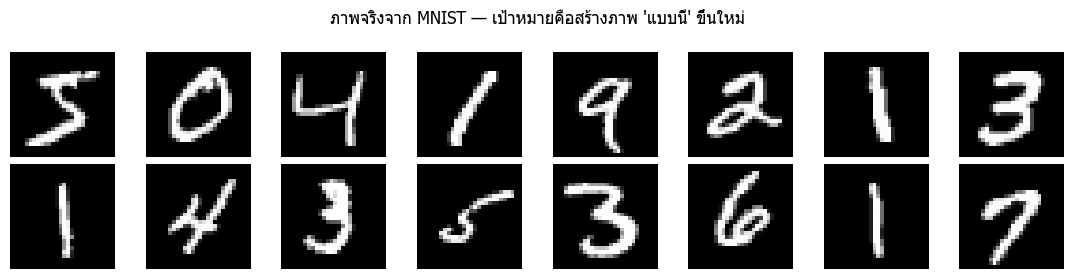

In [1]:
# ── Setup ──
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel("ERROR")

plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False

# โหลด MNIST
(x_train, y_train), _ = keras.datasets.mnist.load_data()
x01 = (x_train / 255.0).astype("float32")               # ช่วง [0,1] (ใช้กับ VAE)
print("MNIST:", x01.shape)

# ดูภาพจริงที่โมเดลจะพยายามเลียนแบบ
fig, ax = plt.subplots(2, 8, figsize=(11, 2.8))
for k, a in enumerate(ax.flat):
    a.imshow(x01[k], cmap="gray"); a.axis("off")
plt.suptitle("ภาพจริงจาก MNIST — เป้าหมายคือสร้างภาพ 'แบบนี้' ขึ้นใหม่")
plt.tight_layout(); plt.show()

---
## Part 1 — Generative Model คืออะไร

ลองเทียบสองงาน:
- **Discriminative** (เล่ม 1, 3): เรียน $p(y \mid x)$ — "ภาพนี้คือเลขอะไร" (รับภาพ → ทาย)
- **Generative** (เล่มนี้): เรียน $p(x)$ — "ภาพเลขเขียนมือ *หน้าตาเป็นยังไง*" แล้ว**สุ่มภาพใหม่**ออกมาได้

ความท้าทาย: ภาพ 28×28 มี 784 pixel = ปริภูมิ 784 มิติ แต่ภาพที่ "ดูเหมือนเลขจริง" เป็นเพียงพื้นผิวบาง ๆ
(manifold) ในปริภูมินั้น generative model ต้องเรียนว่าพื้นผิวนี้อยู่ตรงไหน แล้วสุ่มจุดบนมันให้ได้

ทั้ง 3 โมเดลแก้ปัญหานี้คนละมุม — มาสร้างทีละตัวแล้วเทียบกัน

---
## Part 2 — VAE (Variational Autoencoder)

เริ่มจาก **autoencoder** ธรรมดา: encoder บีบภาพ → เวกเตอร์เล็ก ๆ (latent), decoder คลายกลับเป็นภาพ
ปัญหา: latent ของ autoencoder ธรรมดา "เป็นรู ๆ" — สุ่มจุดใหม่มาคลายมักได้ภาพขยะ

**VAE** แก้โดยบังคับให้ latent เป็น**การแจกแจงต่อเนื่อง** (ใกล้ ๆ การแจกแจงปกติ) จึงสุ่มจุดใหม่มาสร้างภาพได้

- encoder พ่นออกมาเป็น **mean (μ) และ variance (σ²)** ของ latent (ไม่ใช่ค่าเดียว)
- **reparameterization trick**: สุ่ม $z = \mu + \sigma \cdot \epsilon$ (โดย $\epsilon \sim N(0,1)$) — เขียนแบบนี้ทำให้ gradient ไหลผ่านการสุ่มได้
- loss มี 2 ก้อน:
  - **reconstruction** — ภาพที่คลายกลับต้องเหมือนต้นฉบับ
  - **KL divergence** — บังคับ latent ให้เกาะกลุ่มใกล้ $N(0,1)$ (เพื่อให้สุ่มสร้างได้)

In [2]:
# ── VAE: latent 2 มิติ (เพื่อ visualize ได้สวย) ──
keras.utils.set_random_seed(0)
LATENT = 2

encoder = keras.Sequential([
    keras.Input((28, 28)), layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(2 * LATENT),                 # พ่น [mean(2), logvar(2)]
], name="encoder")
decoder = keras.Sequential([
    keras.Input((LATENT,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(784, activation="sigmoid"),
    layers.Reshape((28, 28)),
], name="decoder")

opt = keras.optimizers.Adam(1e-3)

@tf.function
def train_vae(xb):
    with tf.GradientTape() as tape:
        h = encoder(xb)
        mean, logvar = h[:, :LATENT], h[:, LATENT:]
        eps = tf.random.normal(tf.shape(mean))
        z = mean + tf.exp(0.5 * logvar) * eps              # reparameterization trick
        xr = decoder(z)
        # reconstruction = binary cross-entropy รวมทุก pixel
        xb_f = tf.reshape(xb, (tf.shape(xb)[0], -1))
        xr_f = tf.clip_by_value(tf.reshape(xr, (tf.shape(xb)[0], -1)), 1e-7, 1 - 1e-7)
        rec = -tf.reduce_sum(xb_f * tf.math.log(xr_f) + (1 - xb_f) * tf.math.log(1 - xr_f), axis=1)
        # KL divergence ระหว่าง latent กับ N(0,1)
        kl = -0.5 * tf.reduce_sum(1 + logvar - mean**2 - tf.exp(logvar), axis=1)
        loss = tf.reduce_mean(rec + kl)
    v = encoder.trainable_variables + decoder.trainable_variables
    opt.apply_gradients(zip(tape.gradient(loss, v), v))
    return loss

ds = tf.data.Dataset.from_tensor_slices(x01).shuffle(10000).batch(128)
t0 = time.time()
for ep in range(20):
    for xb in ds: loss = train_vae(xb)
print(f"VAE train เสร็จใน {time.time()-t0:.0f}s | loss {float(loss):.1f}")

VAE train เสร็จใน 36s | loss 156.2


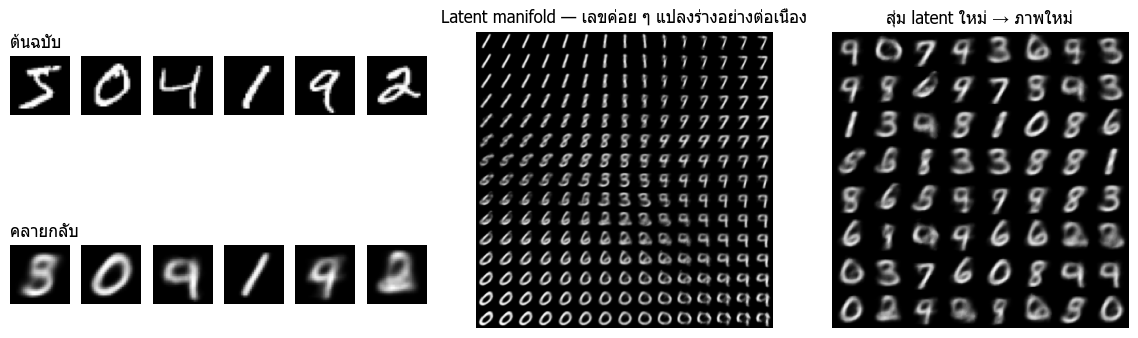

จุดเด่น VAE: latent space ต่อเนื่องลื่น (เห็นจาก manifold) | จุดด้อย: ภาพ 'เบลอ' เพราะ loss เฉลี่ยทุก pixel


In [3]:
# ── ผลของ VAE: reconstruction + latent manifold + สุ่มภาพใหม่ ──
fig = plt.figure(figsize=(13, 4.5))

# (1) reconstruction: ต้นฉบับ vs ที่คลายกลับ
gs1 = fig.add_gridspec(2, 6, left=0.04, right=0.36)
h = encoder(x01[:6]); z = h[:, :LATENT]
recon = decoder(z).numpy()
for j in range(6):
    a = fig.add_subplot(gs1[0, j]); a.imshow(x01[j], cmap="gray"); a.axis("off")
    if j == 0: a.set_title("ต้นฉบับ", loc="left")
    b = fig.add_subplot(gs1[1, j]); b.imshow(recon[j], cmap="gray"); b.axis("off")
    if j == 0: b.set_title("คลายกลับ", loc="left")

# (2) latent manifold: คลายจุดบน grid ของ latent space
ax2 = fig.add_subplot(1, 3, 2)
n = 15; grid = np.linspace(-2.5, 2.5, n); canvas = np.zeros((28*n, 28*n))
for i, yi in enumerate(grid):
    for j, xi in enumerate(grid):
        canvas[i*28:(i+1)*28, j*28:(j+1)*28] = decoder(np.array([[xi, yi]], "float32")).numpy()[0]
ax2.imshow(canvas, cmap="gray"); ax2.axis("off")
ax2.set_title("Latent manifold — เลขค่อย ๆ แปลงร่างอย่างต่อเนื่อง")

# (3) สุ่มจาก N(0,1) สร้างภาพใหม่
ax3 = fig.add_subplot(1, 3, 3)
samples = decoder(np.random.normal(size=(64, LATENT)).astype("float32")).numpy()
big = np.zeros((28*8, 28*8))
for k in range(64):
    big[28*(k//8):28*(k//8+1), 28*(k%8):28*(k%8+1)] = samples[k]
ax3.imshow(big, cmap="gray"); ax3.axis("off")
ax3.set_title("สุ่ม latent ใหม่ → ภาพใหม่")
plt.show()
print("จุดเด่น VAE: latent space ต่อเนื่องลื่น (เห็นจาก manifold) | จุดด้อย: ภาพ 'เบลอ' เพราะ loss เฉลี่ยทุก pixel")

---
## Part 3 — GAN (Generative Adversarial Network)

ไอเดียสุดบรรเจิด: ให้ **2 network แข่งกัน** เหมือนเกมระหว่างนักปลอมแบงก์กับตำรวจ

- **Generator** — รับ noise สุ่ม → พยายามสร้างภาพปลอมให้เนียนที่สุด
- **Discriminator** — รับภาพ → ทายว่า "จริง (จาก MNIST)" หรือ "ปลอม (จาก generator)"

ทั้งคู่ฝึกพร้อมกันแบบปะทะ (adversarial): discriminator เก่งขึ้นเรื่อย ๆ ในการจับของปลอม
บีบให้ generator ต้องสร้างของที่เนียนขึ้นเรื่อย ๆ — สุดท้าย generator วาดเลขได้เนียนจนแยกไม่ออก

$$\min_G \max_D \; \mathbb{E}_{x}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))]$$

GAN ให้ภาพ**คมกว่า VAE** (ไม่มี loss เฉลี่ย pixel มากดให้เบลอ) แต่ขึ้นชื่อเรื่อง **train ยาก**:
ถ้าฝ่ายใดฝ่ายหนึ่งเก่งนำไปไกล อีกฝ่ายจะเรียนไม่ได้ และอาจเกิด **mode collapse** (generator วาดได้ไม่กี่แบบซ้ำ ๆ)

In [4]:
# ── GAN (DCGAN): generator + discriminator ──
keras.utils.set_random_seed(0)
xg = (x01[:20000] * 2 - 1).astype("float32")[..., None]   # สเกล [-1,1] ให้เข้ากับ tanh, เพิ่ม channel
NOISE = 100

generator = keras.Sequential([
    keras.Input((NOISE,)),
    layers.Dense(7*7*128), layers.BatchNormalization(), layers.ReLU(),
    layers.Reshape((7, 7, 128)),
    layers.Conv2DTranspose(64, 4, strides=2, padding="same"),    # 7x7 -> 14x14
    layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh"),  # 14 -> 28
], name="generator")

discriminator = keras.Sequential([
    keras.Input((28, 28, 1)),
    layers.Conv2D(64, 4, strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Conv2D(128, 4, strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Flatten(), layers.Dense(1),                          # logit: จริง/ปลอม
], name="discriminator")

g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
bce = keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_gan(real):
    b = tf.shape(real)[0]
    # --- ฝึก discriminator: แยกจริงออกจากปลอม ---
    noise = tf.random.normal((b, NOISE))
    with tf.GradientTape() as dt:
        fake = generator(noise, training=True)
        d_real = discriminator(real, training=True)
        d_fake = discriminator(fake, training=True)
        d_loss = bce(tf.ones_like(d_real) * 0.9, d_real) + bce(tf.zeros_like(d_fake), d_fake)  # label smoothing
    d_opt.apply_gradients(zip(dt.gradient(d_loss, discriminator.trainable_variables),
                              discriminator.trainable_variables))
    # --- ฝึก generator: หลอกให้ discriminator คิดว่าปลอม = จริง ---
    noise = tf.random.normal((b, NOISE))
    with tf.GradientTape() as gt:
        fake = generator(noise, training=True)
        d_fake = discriminator(fake, training=True)
        g_loss = bce(tf.ones_like(d_fake), d_fake)
    g_opt.apply_gradients(zip(gt.gradient(g_loss, generator.trainable_variables),
                              generator.trainable_variables))
    return d_loss, g_loss

ds = tf.data.Dataset.from_tensor_slices(xg).shuffle(10000).batch(128, drop_remainder=True)
t0 = time.time()
for ep in range(20):
    for real in ds: d_loss, g_loss = train_gan(real)
    if ep % 4 == 0:
        print(f"   epoch {ep:2d}: d_loss {float(d_loss):.2f}  g_loss {float(g_loss):.2f}  ({time.time()-t0:.0f}s)")
print(f"GAN train เสร็จใน {time.time()-t0:.0f}s (d_loss กับ g_loss ควรสูสีกัน = สมดุล ไม่มีใครชนะขาด)")

   epoch  0: d_loss 1.08  g_loss 1.01  (17s)


   epoch  4: d_loss 1.26  g_loss 0.97  (79s)


   epoch  8: d_loss 1.29  g_loss 0.78  (140s)


   epoch 12: d_loss 1.31  g_loss 0.96  (201s)


   epoch 16: d_loss 1.31  g_loss 0.84  (262s)


GAN train เสร็จใน 308s (d_loss กับ g_loss ควรสูสีกัน = สมดุล ไม่มีใครชนะขาด)


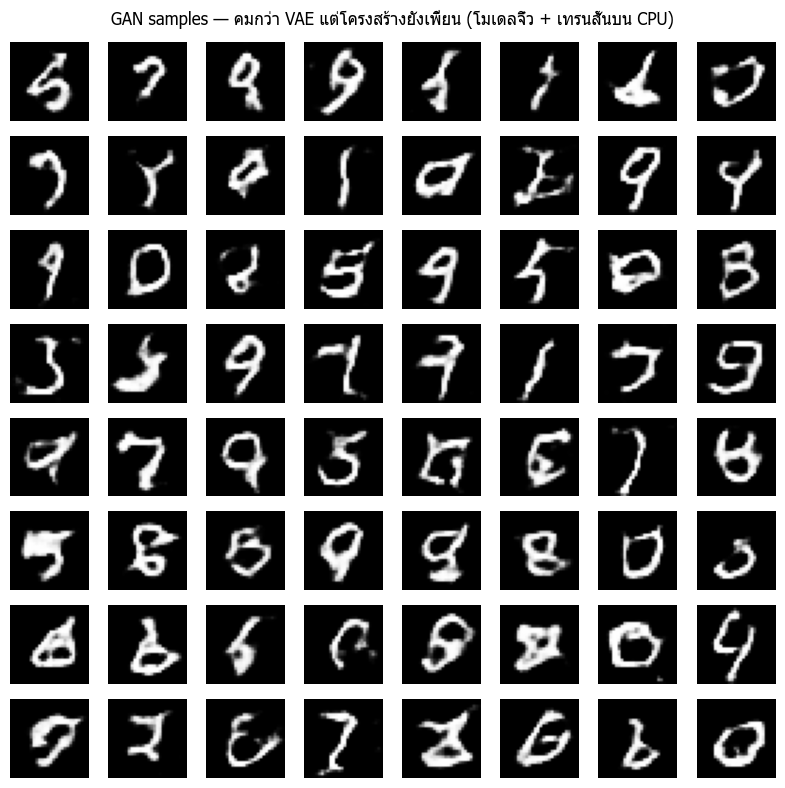

สังเกต: เส้นคมชัดกว่าภาพเบลอ ๆ ของ VAE — แต่หลายตัวยังไม่เป็นเลขชัด
GAN ของจริงต้องเทรนนานกว่านี้มาก + ปรับ hyperparameter ละเอียด ขึ้นชื่อว่า 'เลี้ยงยาก'


In [5]:
# ── ภาพที่ generator วาดได้ ──
keras.utils.set_random_seed(123)
samples = generator(tf.random.normal((64, NOISE)), training=False).numpy()
samples = (samples + 1) / 2                                # กลับมา [0,1]

fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for k, a in enumerate(ax.flat):
    a.imshow(samples[k, ..., 0], cmap="gray"); a.axis("off")
plt.suptitle("GAN samples — คมกว่า VAE แต่โครงสร้างยังเพี้ยน (โมเดลจิ๋ว + เทรนสั้นบน CPU)")
plt.tight_layout(); plt.show()
print("สังเกต: เส้นคมชัดกว่าภาพเบลอ ๆ ของ VAE — แต่หลายตัวยังไม่เป็นเลขชัด")
print("GAN ของจริงต้องเทรนนานกว่านี้มาก + ปรับ hyperparameter ละเอียด ขึ้นชื่อว่า 'เลี้ยงยาก'")

---
## Part 4 — Diffusion Models (เบื้องหลัง Stable Diffusion / DALL·E)

แนวคิดที่ครองวงการ image generation ยุคนี้ — และไอเดียสวยงามอย่างเหลือเชื่อ แบ่งเป็น 2 ทาง:

- **Forward process** (กำหนดตายตัว ไม่ต้องเรียน): ค่อย ๆ เติม noise ลงภาพจริงทีละนิด ผ่าน $T$ ขั้น
  จนภาพกลายเป็น **noise ขาว ๆ ล้วน** สมบูรณ์
- **Reverse process** (สิ่งที่ต้องเรียน): สอน neural net ให้ทำ**ย้อนกลับ** — รับภาพมี noise + บอกว่าอยู่ขั้นไหน
  แล้ว**ทำนาย noise** ที่ปนอยู่ เพื่อค่อย ๆ ถอย noise ออกทีละขั้น

พอเทรนเสร็จ การสร้างภาพใหม่ก็แค่: **เริ่มจาก noise ล้วน → ให้โมเดลถอย noise ทีละขั้นจนได้ภาพ**

มาดู forward process ก่อน (ส่วนนี้ไม่ต้องเทรน — แค่เติม noise ตามสูตร):

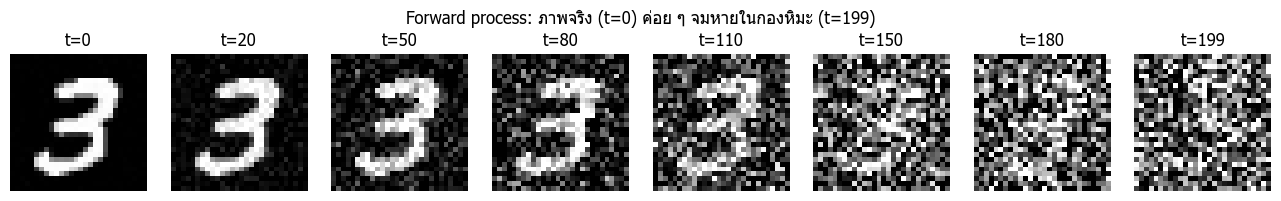

In [6]:
# ── Forward process: เติม noise ทีละขั้นจนภาพหายเป็นหิมะ ──
T = 200                                                   # จำนวนขั้น noise ทั้งหมด
betas = np.linspace(1e-4, 0.02, T).astype("float32")      # ปริมาณ noise ที่เติมแต่ละขั้น
alphas = 1.0 - betas
alpha_bar = np.cumprod(alphas).astype("float32")          # สัดส่วนภาพเดิมที่เหลือ ณ ขั้น t
alpha_bar_t = tf.constant(alpha_bar)

# สูตร: x_t = sqrt(ᾱ_t) · x_0  +  sqrt(1-ᾱ_t) · noise   (กระโดดไปขั้นไหนก็ได้ในครั้งเดียว)
img0 = (x01[7] * 2 - 1)                                    # เลขจริงหนึ่งใบ ([-1,1])
fig, ax = plt.subplots(1, 8, figsize=(13, 2))
for k, t in enumerate([0, 20, 50, 80, 110, 150, 180, 199]):
    a = alpha_bar[t]
    noised = np.sqrt(a) * img0 + np.sqrt(1 - a) * np.random.normal(size=img0.shape)
    ax[k].imshow(((noised + 1) / 2).clip(0, 1)[..., 0] if noised.ndim == 3 else ((noised+1)/2).clip(0,1),
                 cmap="gray")
    ax[k].set_title(f"t={t}"); ax[k].axis("off")
plt.suptitle("Forward process: ภาพจริง (t=0) ค่อย ๆ จมหายในกองหิมะ (t=199)")
plt.tight_layout(); plt.show()

In [7]:
# ── โมเดลถอย noise: UNet จิ๋ว (รับภาพ+ขั้น t -> ทำนาย noise) ──
class TimeEmbedding(layers.Layer):
    """แปลงเลขขั้น t เป็นเวกเตอร์ (sinusoidal) ให้โมเดลรู้ว่ากำลัง denoise ขั้นไหน"""
    def __init__(self, dim=64):
        super().__init__(); self.dim = dim; self.dense = layers.Dense(64, activation="swish")
    def call(self, t):
        half = self.dim // 2
        freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
        args = tf.cast(t[:, None], tf.float32) * freqs[None, :]
        return self.dense(tf.concat([tf.sin(args), tf.cos(args)], axis=1))

class UNet(keras.Model):
    """UNet ย่อส่วน: หด-ขยายภาพพร้อม skip connection + ฉีดข้อมูลขั้น t เข้าทุกชั้น"""
    def __init__(self):
        super().__init__()
        self.temb = TimeEmbedding(64)
        self.t1 = layers.Dense(32); self.t2 = layers.Dense(64)
        self.t3 = layers.Dense(128); self.tu2 = layers.Dense(128)
        self.c1 = layers.Conv2D(32, 3, padding="same", activation="swish")
        self.c2 = layers.Conv2D(64, 3, strides=2, padding="same", activation="swish")   # 28->14
        self.c3 = layers.Conv2D(128, 3, strides=2, padding="same", activation="swish")  # 14->7
        self.cmid = layers.Conv2D(128, 3, padding="same", activation="swish")
        self.u2 = layers.Conv2DTranspose(64, 4, strides=2, padding="same", activation="swish")  # 7->14
        self.u1 = layers.Conv2DTranspose(32, 4, strides=2, padding="same", activation="swish")  # 14->28
        self.out = layers.Conv2D(1, 3, padding="same")
    def call(self, inputs):
        img, t = inputs; e = self.temb(t)
        h1 = self.c1(img) + self.t1(e)[:, None, None, :]
        h2 = self.c2(h1)  + self.t2(e)[:, None, None, :]
        h3 = self.c3(h2)  + self.t3(e)[:, None, None, :]
        h3 = self.cmid(h3)
        u2 = self.u2(h3); u2 = tf.concat([u2, h2], -1) + self.tu2(e)[:, None, None, :]  # skip connection
        u1 = self.u1(u2); u1 = tf.concat([u1, h1], -1)
        return self.out(u1)

keras.utils.set_random_seed(0)
xd = (x01[:20000] * 2 - 1).astype("float32")[..., None]
unet = UNet(); opt_d = keras.optimizers.Adam(1e-3)

@tf.function
def train_diffusion(x0):
    b = tf.shape(x0)[0]
    t = tf.random.uniform((b,), 0, T, dtype=tf.int32)              # สุ่มขั้น noise
    noise = tf.random.normal(tf.shape(x0))
    a = tf.gather(alpha_bar_t, t)[:, None, None, None]
    xt = tf.sqrt(a) * x0 + tf.sqrt(1 - a) * noise                  # เติม noise (forward)
    with tf.GradientTape() as tape:
        pred = unet([xt, t], training=True)
        loss = tf.reduce_mean((pred - noise) ** 2)                 # เป้าหมาย: ทำนาย noise ที่เติมเข้าไป
    opt_d.apply_gradients(zip(tape.gradient(loss, unet.trainable_variables), unet.trainable_variables))
    return loss

ds = tf.data.Dataset.from_tensor_slices(xd).shuffle(10000).batch(128, drop_remainder=True)
t0 = time.time()
for ep in range(15):
    for xb in ds: loss = train_diffusion(xb)
    if ep % 3 == 0: print(f"   epoch {ep:2d}: loss {float(loss):.3f}  ({time.time()-t0:.0f}s)")
print(f"Diffusion train เสร็จใน {time.time()-t0:.0f}s")

   epoch  0: loss 0.200  (19s)


   epoch  3: loss 0.102  (69s)


   epoch  6: loss 0.098  (120s)


   epoch  9: loss 0.071  (170s)


   epoch 12: loss 0.072  (226s)


Diffusion train เสร็จใน 265s


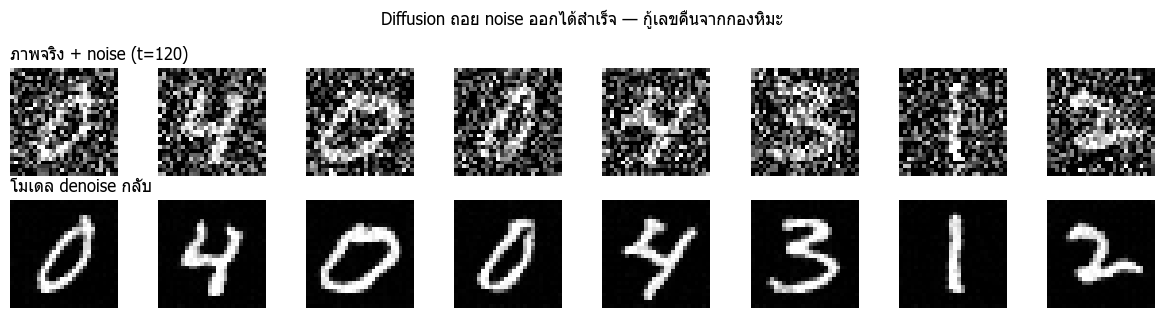

In [8]:
# ── reverse process: ถอย noise ทีละขั้น ──
def reverse_from(xt, start_t):
    """เริ่มจาก xt ที่ขั้น start_t แล้วถอย noise ลงมาจนถึงภาพสะอาด (t=0)"""
    for i in reversed(range(start_t)):
        tt = tf.fill((tf.shape(xt)[0],), i)
        pred = unet([xt, tt], training=False)                      # ทำนาย noise
        a, b, al = alpha_bar[i], betas[i], alphas[i]
        mean = (xt - b / np.sqrt(1 - a) * pred) / np.sqrt(al)      # สูตรถอย noise ของ DDPM
        xt = mean + np.sqrt(b) * tf.random.normal(tf.shape(xt)) if i > 0 else mean
    return xt.numpy()

to01 = lambda z: ((z + 1) / 2).clip(0, 1)

# ★ พระเอก: เอาภาพจริงมาใส่ noise ครึ่งทาง (t=120) แล้วให้โมเดล denoise กลับ
keras.utils.set_random_seed(3)
reals = xd[np.random.default_rng(1).integers(0, len(xd), 8)]
tmid = 120; a = alpha_bar[tmid]
noised = (np.sqrt(a) * reals + np.sqrt(1 - a) * np.random.normal(size=reals.shape)).astype("float32")
denoised = reverse_from(tf.constant(noised), tmid)

fig, ax = plt.subplots(2, 8, figsize=(12, 3.2))
for j in range(8):
    ax[0, j].imshow(to01(noised[j, ..., 0]), cmap="gray"); ax[0, j].axis("off")
    ax[1, j].imshow(to01(denoised[j, ..., 0]), cmap="gray"); ax[1, j].axis("off")
ax[0, 0].set_title("ภาพจริง + noise (t=120)", loc="left")
ax[1, 0].set_title("โมเดล denoise กลับ", loc="left")
plt.suptitle("Diffusion ถอย noise ออกได้สำเร็จ — กู้เลขคืนจากกองหิมะ")
plt.tight_layout(); plt.show()

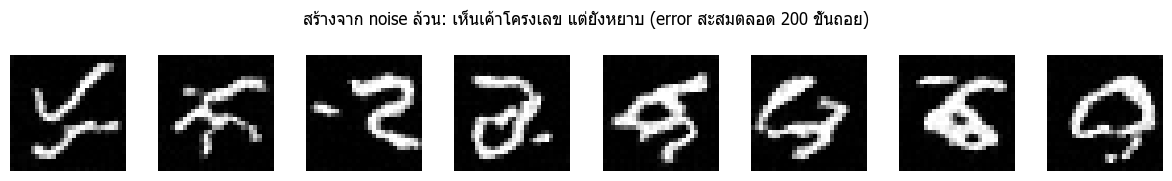

ทำไม denoise ภาพจริง (ด้านบน) ชัดกว่า generate จากศูนย์ (ด้านนี้)?
  - denoise เริ่มจาก 'โครงเลขจริง' ที่ฝังอยู่ใต้ noise -> ง่าย
  - generate เริ่มจาก noise ล้วน ไม่มีโครง -> โมเดลจิ๋วของเราพลังไม่พอ error เลยสะสม
  ของจริง (Stable Diffusion) แก้ด้วยโมเดลมหึมา + เทรนบน GPU นานมาก + เทคนิคเพียบ


In [9]:
# ── generate จาก noise ล้วน (โจทย์ยากสุด) — ดูตามจริง ──
keras.utils.set_random_seed(7)
generated = reverse_from(tf.random.normal((8, 28, 28, 1)), T)

fig, ax = plt.subplots(1, 8, figsize=(12, 1.8))
for j in range(8):
    ax[j].imshow(to01(generated[j, ..., 0]), cmap="gray"); ax[j].axis("off")
plt.suptitle("สร้างจาก noise ล้วน: เห็นเค้าโครงเลข แต่ยังหยาบ (error สะสมตลอด 200 ขั้นถอย)")
plt.tight_layout(); plt.show()
print("ทำไม denoise ภาพจริง (ด้านบน) ชัดกว่า generate จากศูนย์ (ด้านนี้)?")
print("  - denoise เริ่มจาก 'โครงเลขจริง' ที่ฝังอยู่ใต้ noise -> ง่าย")
print("  - generate เริ่มจาก noise ล้วน ไม่มีโครง -> โมเดลจิ๋วของเราพลังไม่พอ error เลยสะสม")
print("  ของจริง (Stable Diffusion) แก้ด้วยโมเดลมหึมา + เทรนบน GPU นานมาก + เทคนิคเพียบ")

---
## Part 5 — เทียบ 3 ตระกูล + สรุป

| | **VAE** | **GAN** | **Diffusion** |
|---|---|---|---|
| ไอเดีย | บีบ→สุ่ม→คืน | generator ปะทะ discriminator | เติม noise แล้วเรียนถอย |
| คุณภาพภาพ | เบลอ | คม (แต่อาจเพี้ยน) | คมและหลากหลายสุด (ที่สเกลใหญ่) |
| ความเสถียรตอนเทรน | เสถียรมาก | **ยากสุด** (mode collapse) | เสถียร |
| ความเร็วตอนสร้าง | เร็ว (1 ครั้ง) | เร็ว (1 ครั้ง) | **ช้า** (ถอยหลายขั้น) |
| latent ที่ตีความได้ | ✔ (เห็น manifold) | ปานกลาง | ไม่เน้น |
| ใช้จริงยุคนี้ | บีบข้อมูล/ตรวจ anomaly | สังเคราะห์ภาพ/เสียง | **ครองวงการ image gen** |

> **generative model มี 4 ตระกูลหลัก** — เล่มนี้ทำครบ 3 ฝั่งภาพ ส่วนตระกูลที่ 4 คือ **autoregressive**
> (ทำนายทีละชิ้นต่อกัน) ซึ่งเราสร้างไปแล้วในเล่ม 2 (mini GPT สร้างข้อความทีละ token)!

### 🌍 ของจริงในโลก
- **Stable Diffusion / DALL·E / Midjourney** = diffusion (Part 4) ขยายสเกลมหาศาล + เงื่อนไขด้วยข้อความ (text-to-image)
- **StyleGAN** = GAN (Part 3) ที่สร้างภาพใบหน้าคนสมจริงจนแยกไม่ออก
- **VAE** = ส่วนประกอบใน Stable Diffusion เอง (บีบภาพเป็น latent ก่อน diffuse — ประหยัด compute)

### 🎓 สรุปทั้ง 5 เล่ม
| เล่ม | แก่น |
|---|---|
| 1 — ML Fundamentals | neuron → CNN → attention → mini GPT |
| 2 — LLM Deep Dive | tokenizer → pretrain → fine-tune (generative: ข้อความ) |
| 3 — ML × Network Security | classical ML + unsupervised + adversarial |
| 4 — Reinforcement Learning | Q-learning → DQN → REINFORCE → RLHF |
| 5 — Generative Vision | VAE → GAN → Diffusion (generative: ภาพ) |

> ครบทั้ง 3 paradigm + generative ทั้งข้อความและภาพ + security + RL
> แก่นเดียวกันหมด: **forward → loss → backprop → update** ต่างกันแค่ "loss วัดอะไร" และ "ประกอบ neuron ยังไง"

### แหล่งเรียนรู้ต่อ
- 📄 *Auto-Encoding Variational Bayes* (Kingma & Welling, 2013) — ต้นตำรับ VAE
- 📄 *Generative Adversarial Networks* (Goodfellow et al., 2014) — ต้นตำรับ GAN
- 📄 *Denoising Diffusion Probabilistic Models* (Ho et al., 2020) — ต้นตำรับ DDPM
- 🎬 Karpathy / Hugging Face *Diffusion Models* course — ลงมือสร้าง diffusion จริงจัง